<a href="https://colab.research.google.com/github/Gowtham13042007/cron_job/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import random

def createClusteredData(N,k):
  random.seed(0)
  pointsPerCluster=float(N)/k
  X=[]
  y=[]
  for i in range(k):
    incomeCentriod=random.uniform(20000.0,200000.0)
    ageCentriod=random.uniform(20.0,70.0)
    for j in range(int(pointsPerCluster)):
      X.append([np.random.normal(incomeCentriod,10000.0),np.random.normal(ageCentriod,2.0)])
      y.append(i)
  X=np.array(X)
  y=np.array(y)
  return X,y

MinMaxScaler(feature_range=(-1, 1))


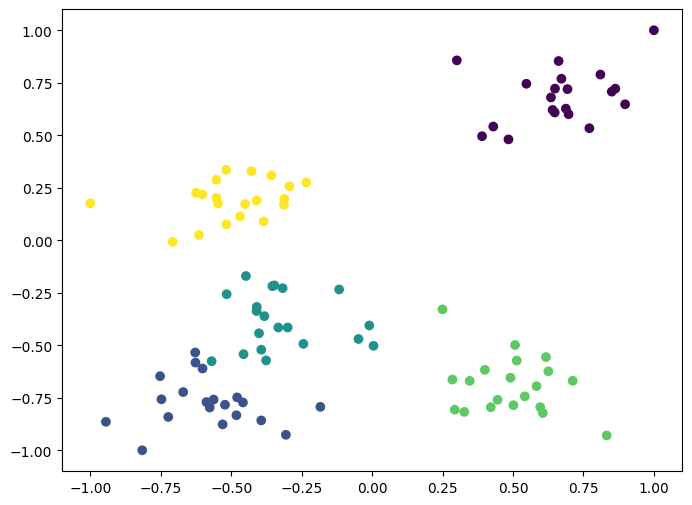

In [11]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

(X,y)=createClusteredData(100,5)

scaling=MinMaxScaler(feature_range=(-1,1)).fit(X)   #it learns the statistics
X=scaling.transform(X)    #here is where the statstics happens

plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1],c=y.astype(float))
plt.show()

In [16]:
from sklearn import svm,datasets

C=1.0
svc=svm.SVC(kernel='linear',C=C).fit(X,y)
print(svc)

SVC(kernel='linear')


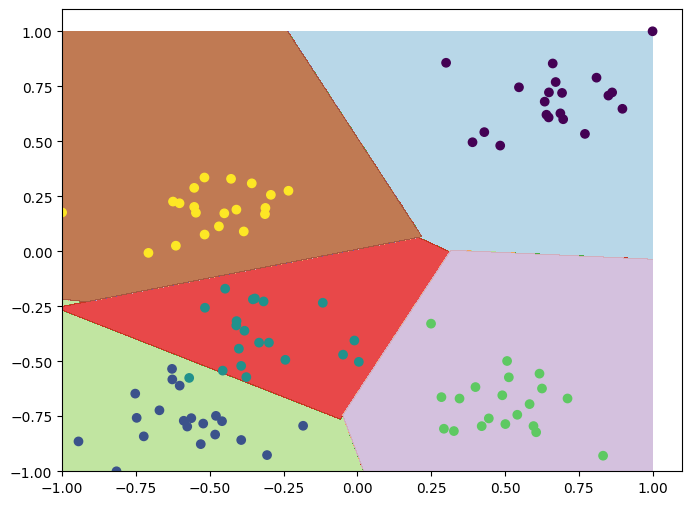

In [19]:
import numpy as np
import matplotlib.pyplot as plt
def plotPredicitions(clf):
  xx,yy=np.meshgrid(np.arange(-1.0,1.0,0.001),np.arange(-1,1,0.001))
  npx=xx.ravel()   # 2d to 1d
  npy=yy.ravel()

  samplePoints=np.c_[npx,npy]  #sample points
  Z=clf.predict(samplePoints)   # predicts the class of each point
  Z=Z.reshape(xx.shape)  # from 1D to 2D
  plt.figure(figsize=(8,6))
  plt.contourf(xx,yy,Z,cmap=plt.cm.Paired,alpha=0.8)  # alpha 1(visible) 0(invisble)
  plt.scatter(X[:,0],X[:,1],c=y.astype(float))
  plt.show()
plotPredicitions(svc)

In [24]:
print(svc.predict(scaling.transform([[2000,40]])))

[1]
